In [ ]:
import sys, os
from pathlib import Path
from pprint import pprint
from collections import defaultdict

import numpy as np
import torch
import networkx as nx
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
from tqdm import tqdm

from sklearn.metrics import precision_recall_fscore_support#confusion_matrix

import yaml

BASE_DIR = Path.cwd().resolve().parent.parent
sys.path.append(str(BASE_DIR))
SCRIPT_DIR = Path.cwd().resolve()
CFG_DIR = SCRIPT_DIR / 'configs'
RESULTS_DIR = SCRIPT_DIR / 'results'


from src.models.lr_ssd.snn__logn_gtv import SNN__LOGN_GTV
from src.models.tucker_decomp.hosvd import hosvd
from src.metrics.estimate_rank import estimate_tucker_rank
from src.multilinear_ops.matricize import matricize

from src.multilinear_ops.mode_product import mode_product

from src.gsp.gsp_vis import draw_graph_signal
# Class used to import Server Machine Dataset and NYC Taxi Dataset with 
# Spatial and Temporal Graphs
from data.server_machine_dataset import SMDMachineChannel
from data.nyc_taxi_dataset import NYCTaxiDataset
from data.hsi_abu_dataset import ABUHyperSpectral


plt.style.use('seaborn-v0_8-paper')
# Set the default font family to serif
plt.rcParams['font.family'] = 'serif' 
# Specify a list of font names to try for the serif family
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Palatino']

: 

## Exploratory Data Analysis for HSI ABU Anomaly Detection Dataset
Let's start with visualizing one of the hyper-spectral images.

In [2]:
from IPython.display import HTML
abuhsi = ABUHyperSpectral('urban', 2)

# plt.imshow(abuhsi.Y[...,0])
fig, ax, ani = abuhsi.animate();
# plt.close()
htmlvid = ani.to_html5_video();
HTML(htmlvid)
# fig, ax, ani = abuhsi.animate(save_dir='./visuals/')

### Histogram w.r.t. Spectral Bands


Text(0.5, 0.98, 'Histograms for every spectral band in the image')

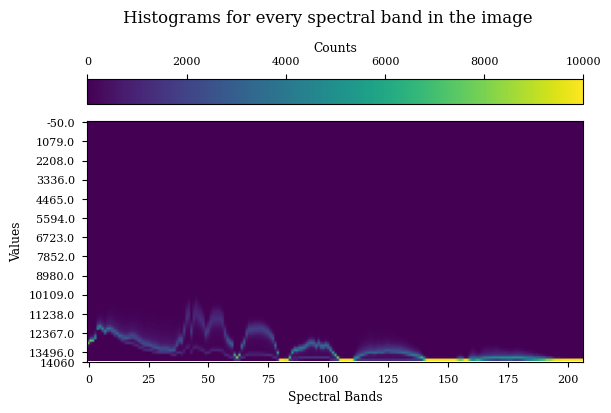

In [3]:
fig, axes = plt.subplots(nrows=1, ncols=1)
axes = [axes]
nbands = abuhsi.Y.shape[2]
vmin = np.min(abuhsi.Y)
vmax = np.max(abuhsi.Y)
bins = 100
Ys = matricize(abuhsi.Y, [3])
hist = np.zeros((nbands, bins))
for s in range(nbands):
    hst, edges = np.histogram(Ys[s,:], bins=bins, range=(vmin, vmax))
    hist[s, :] = hst

hist_plot = axes[0].imshow(hist[...,::-1].T, cmap='viridis')
axes[0].set_xlabel("Spectral Bands")
axes[0].set_ylabel("Values")
axes[0].set_yticks(np.arange(0,bins, 8).tolist() + [bins],
                   np.linspace(vmin, vmax, bins,endpoint=False
                               ).round()[::8].tolist() + [vmax])
# ax.set_yticks()
fig.colorbar(hist_plot, location='top', label='Counts')
fig.suptitle("Histograms for every spectral band in the image")

## Example run of SNN__LOGN_GTV on Airport-1

In [18]:
from src.models.lr_ssd.snn__logn_gtv import SNN__LOGN_GTV

model_keys = ['HoRPCA',
            'SNN_LOGNTE',
            'SNN_LOGN', 
            'SNN_LOGNST',
            'SNN_L1_GTV_T',
            'SNN_L1_GTVS_sn',
            'SNN_LOGN_SN_GTV_T',
            "SNN_LOGN_SN_GTV_S",
            'SNN_LOGNST_GTVST',
            ]
with open(CFG_DIR / 'model_configs.yaml') as f:
    model_configs = yaml.safe_load(f)
model_names = [ model_configs[key]['name'] for key in model_keys]

model_key = 'SNN_LOGNST'
category = 'airport'
image_id = 1
k=1.0
data = ABUHyperSpectral(category,image_id)
Y = data.Y
variance_estimate = data.variance_estimates[category][image_id-1]
sigma = variance_estimate**0.5
model_config = model_configs[model_key]
model_select = { # Model selection based on the model_config
            'graph': model_config['graph'],
            'lr_modes': [1,2,3],
            'graph_modes': model_config['graph_modes'],
            'grouping': model_config['grouping'],
            'weighing': 'size_normalized',#'uniform', #'size_normalized_inv', #, #,#'uniform',#'uniform',#model_config['weighing'],
            'r_hop': model_config['r_hop'],
            'soft_constrained': False, #model_config.get('soft_constrained', False),
            'device': model_config.get('device', 'cuda' if torch.cuda.is_available() else 'cpu'),
            'dtype': model_config.get('dtype', torch.float64),
            'verbose': 1,
            'gtvr_config': model_config['gtvr_config'],
            'report_freq':249,
            'sp_solve': False,
            'precompute_inv': True,
            }
model_run = {
            'max_iter': 500,#5000,
            'rho': model_config.get('rho', 50.3),
            'err_tol': model_config.get('err_tol', 1e-4),
            'rho_update': 'domain_parametrization', #1,#model_config.get('rho_update', 'domain_parametrization'),
            'rho_update_thr': model_config.get('rho_update_thr', 100)
    }
Gtu = nx.grid_graph((Y.shape[2], ), periodic=False)
Gt = Gtu
Gt = nx.DiGraph([(u, v) for u, v in Gtu.edges() if u <= v and u <= v])

Gsu = nx.grid_graph((Y.shape[0],Y.shape[1]), periodic=False)
Gs = Gsu
Gs = nx.DiGraph([(u, v) for u, v in Gsu.edges() if u[0] <= v[0] and u[1] <= v[1]])
if model_select['graph'] == 'temporal':
    G = Gt
    model_select['graph_modes'] = [3]
elif model_select['graph'] == 'spatial':
    G = Gs
    model_select['graph_modes'] = [1,2]
elif model_select['graph'] == 'spatio-temporal':
    G = nx.cartesian_product(Gs, Gt)
    model_select['graph_modes'] = [1,2,3]
else:
    raise ValueError(f"Unknown graph type: {model_select['graph']}")

Y = data.Y

for g, gtv_regularization in enumerate(model_config['gtvr_config']):
    if gtv_regularization['graph'] == 'temporal':
        gtv_regularization['mode'] = [3]
    elif gtv_regularization['graph'] == 'spatial':
        gtv_regularization['mode'] = [1,2]
    elif gtv_regularization['graph'] == 'spatio-temporal':
        gtv_regularization['mode'] = [1,2,3]
        # gtv_regularization['mode']['p']
    modes = gtv_regularization['mode']
    dims = [Y.shape[m-1] for m in modes]
    num_gtv_vertices = np.prod(dims)
            # sqrt(Estimated variance) * sqrt(2*log(number_of_variates_to_penalize))
            # This is based on the paper "Atomic Decomposition by Basis Pursuit"
model = SNN__LOGN_GTV(Y, G, **model_select)
group_sizes = model.expander.sum(axis=1).to_dense()
group_size_arithmetic_mean = group_sizes.mean().item()
num_groups = model.expander.shape[0]
# group_sizes = model.expander.sum(axis=1).to_dense()
group_size_arithmetic_mean = group_sizes.mean().item()
D= Y.size
lda = 1/(group_size_arithmetic_mean*(np.max(Y.shape)**0.5))
# lda = 1/((np.max(Y.shape))**0.5)
            # sqrt(Estimated variance) * sqrt(2*log(number_of_variates_to_penalize))
            # This is based on the paper "Atomic Decomposition by Basis Pursuit"
# lda_gtvs = [sigma*np.sqrt(2*np.log(num_gtv_vertices))
#             for g in range(len(model_config['gtvr_config']))]
lda_gtvs = [np.sqrt(2*np.log(num_gtv_vertices))
            for g in range(len(model_config['gtvr_config']))]

psis = [1,1,1]
X, S = model(psis,#nn_angle_weights,
            lda,
            lda_gtvs,
             lda_f=1.0,
            **model_run)


scores = (model.S**2).sum(dim=2).sqrt().cpu().numpy()
# scores = np.sum(np.abs(model.S), axis=2)
# scores = np.sum(np.abs(model.S.cpu().numpy()), axis=2)

# std = model.S.std()
t_labels = scores > sigma*k#lda*k


scoring_score = data.anomaly_scoring_score(scores)
detection_score = data.anomaly_detection_score(t_labels)
scoring_score.pop('st_scores', None)
scoring_score.pop('t_scores', None)
results = {**scoring_score, **detection_score}

It-0 	# |r| = 7.2094e+05 	|s| = 4.6816e+07 	 obj = 2.0636e+06 	 0.177 sec.
It-249 	# |r| = 2.2520e+03 	|s| = 3.7753e-02 	 obj = 7.3000e+06 	 0.160 sec.
It-498 	# |r| = 8.2082e+02 	|s| = 5.3958e-03 	 obj = 7.3712e+06 	 0.161 sec.


In [17]:
pprint(results)

{'au_prc': 0.12181167443935857,
 'au_roc': 0.8999756211670275,
 'f1': 0.028413575374901343,
 'precision': 0.014411529223378704,
 'recall': 1.0}


## Estimating Tensor Ranks and Noise Variances on Images

**Note in retrospect:**
We applied the noise estimation method we used in previous experiments, however we later found out that the noisy spectral bands of the data was removed during the pre-processing. Our noise estimation method was not very robust, which we assume was due to this denoising process. Due to this, we set the $\mathrm{[SNN]+[LOGN+GTV]}$ hyper-parameters of the GTV regularization $\lambda_{m}$ slightly differently on this dataset. For the `RTD:OITNN-L`, `RTD:OITNN-O` and `RTD:TNN` models, we set the estimated variance to `0.1`, which is very low when the scale of the values is taken into account. 

defaultdict(<class 'list'>,
            {'raw_': [{'estimated_ranks': [100, 100, 79],
                       'num_param': 799954.0,
                       'r2_value': 0.9999980624107212,
                       'residual_energy': 3580741.5102539062}],
             'raw_r2thr': [{'estimated_ranks': [13, 13, 3],
                            'num_param': 3375.0,
                            'r2_value': 0.990509218963628,
                            'residual_energy': 17539338183.86548}]})


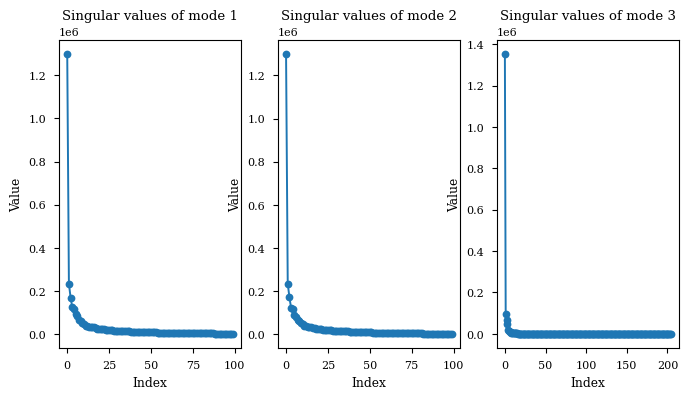

: 

In [ ]:
categories = ['airport', 'beach', 'urban']
img_in_cagegory = {
    'airport':4,
    'beach':4,
    'urban':5,
}

rank_estimates = defaultdict(list)
fig, axes = plt.subplots(1,3, figsize=(8, 4))

Y = hsi_data['data']
hosvd_decomp = hosvd(Y)
svals = hosvd_decomp['svals']

raw_estimation_result = estimate_tucker_rank(Y, method='GCV')
rank_estimates[f'raw_'].append(raw_estimation_result)
rank_estimates[f'raw_r2thr'].append(estimate_tucker_rank(Y, method='core_thresholding', r2_thr=0.99))

for j in range(3):
    ax = axes[j]
    ax.plot(svals[j].cpu().numpy(),
            label=f'Ch', marker='o', linestyle='-')

for i, ax in enumerate(axes):
    ax.set_title(f'Singular values of mode {i+1}')
    ax.set_xlabel('Index')
    ax.set_ylabel('Value')
pprint(rank_estimates)

In [ ]:
r2_thr = 0.99
categories = ['airport', 'beach', 'urban']
img_in_category = {
    'airport':4,
    'beach':4,
    'urban':5,
}
rank_estimates = {'GCV': defaultdict(lambda : {}),
                  'R2': defaultdict(lambda : {})}#defaultdict(list))}

fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(28, 16))
for c, category in tqdm(enumerate(categories)):
    for im_idx in range(1,img_in_category[category]+1):
        hsi_data = sp.io.loadmat(
            f'./results/tensorized_data/hsi_abu/abu-{category}-{im_idx}.mat'
            )
        Y = hsi_data['data']
        D = np.prod(Y.shape)

        ranges = (np.quantile( Y, 0.95, axis=2, keepdims=True))
        scales = np.ones_like(ranges)
        scales[ranges != 0] = 1 / ranges[ranges != 0]
        scaled_Y = Y * scales
        
        rank_estimates['GCV'][category][im_idx] = estimate_tucker_rank(scaled_Y, method='GCV')
            
            
        rank_estimates['R2'][category][im_idx] =  estimate_tucker_rank(
            scaled_Y, method='core_thresholding', r2_thr=r2_thr)
        
        core_dim = rank_estimates['R2'][category][im_idx]['estimated_ranks']
        P = rank_estimates['R2'][category][im_idx]['num_param']
        hosvd_decomp = hosvd(scaled_Y, core_dims=core_dim)
        
        truncated_Y = hosvd_decomp['core']
        for i, mode in enumerate([1, 2, 3]):
            truncated_Y = mode_product(truncated_Y, hosvd_decomp['factors'][i], mode)
        
        residual_Y = scaled_Y - truncated_Y.cpu().numpy()
        median_res = np.median(residual_Y.ravel())
        Q1 = np.quantile(residual_Y.ravel(), 0.25)
        Q3 = np.quantile(residual_Y.ravel(), 0.75)
        IQR = Q3 - Q1
        outlier_labels = (residual_Y < Q1 - 1.5 * IQR) | (residual_Y > Q3 + 1.5 * IQR)
        non_outliers = residual_Y[~outlier_labels]
        # rank_estimates['GCV'][m][ch][-1].update(mchannel.anomaly_scoring_score(np.abs(residual_Y)))
        # rank_estimates['R2'][m][ch][-1].update(mchannel.anomaly_scoring_score(np.abs(residual_Y)))
        # rank_estimates['GCV'][m][ch][-1].update(mchannel.anomaly_detection_score(outlier_labels))
        # rank_estimates['R2'][m][ch][-1].update(mchannel.anomaly_detection_score(outlier_labels))
        # rank_estimates['GCV'][m][ch][-1].pop('st_scores');
        # rank_estimates['GCV'][m][ch][-1].pop('t_scores');
        # rank_estimates['R2'][m][ch][-1].pop('st_scores')
        # rank_estimates['R2'][m][ch][-1].pop('t_scores')
        variance_est = np.var(non_outliers)
        variance_est_corrected = variance_est * (D/(D - P))
        rank_estimates['GCV'][category][im_idx]['variance_estimate']= variance_est_corrected
        rank_estimates['R2'][category][im_idx]['variance_estimate']= variance_est_corrected
        axes[c, im_idx-1].set_title(f'{category}, image {im_idx}')
        axes[c, im_idx-1].hist(residual_Y.ravel(), bins=100, density=True)
        axes[c, im_idx-1].axvline(median_res, color='k', linestyle='dashed', linewidth=1, label='Median')
        axes[c, im_idx-1].axvline(Q1, color='g', linestyle='dashed', linewidth=1, label='Q1')
        axes[c, im_idx-1].axvline(Q3, color='g', linestyle='dashed', linewidth=1, label='Q3')
        axes[c, im_idx-1].axvline(Q1-1.5*IQR, color='r', linestyle='dashed', linewidth=1, label='Q1 - 1.5*IQR')
        axes[c, im_idx-1].axvline(Q3+1.5*IQR, color='r', linestyle='dashed', linewidth=1, label='Q3 + 1.5*IQR')
        axes[c, im_idx-1].grid(True)
        
        
fig.suptitle('Residual Histograms after HOSVD Truncation', fontsize=22, y=0.93)
# pprint(rank_estimates)
categories = [[k for i in range(1, v+1)] for  k, v in img_in_category.items()]
categories = [m for sublist in categories for m in sublist]
images = [[i for i in range(1, v+1)] for  k, v in img_in_category.items()]
images = [ch for sublist in images for ch in sublist]
methods = ['GCV']* len(categories) + ['R2']*len(images)
arrays = [methods, categories*2, images*2]
mindex = pd.MultiIndex.from_arrays(arrays, names=['Method', 'category', 'image_id'])
df_list = [rank_estimates[i][j][k] for i,j,k in mindex]
# df_list = [i for sublist in df_list for i in sublist]  # Flatten the list
df = pd.DataFrame(df_list, index=mindex, columns=rank_estimates['GCV']['airport'][1].keys())

0it [00:00, ?it/s]

1it [00:28, 28.65s/it]

In [ ]:
df

estimated_ranks  num_param  r2_value  \
Method category image_id                                         
GCV    airport  1          [100, 100, 79]   799954.0  0.999997   
                2          [100, 100, 79]   799954.0  0.999997   
                3          [100, 100, 80]   810000.0  0.999997   
                4         [100, 100, 187]  1870748.0  1.000000   
       beach    1          [150, 150, 63]  1425375.0  0.999993   
                2          [100, 100, 79]   799006.0  0.999996   
                3          [100, 100, 78]   788580.0  0.999999   
                4          [150, 150, 85]  1913945.0  0.999980   
       urban    1         [100, 100, 107]  1080379.0  0.999999   
                2         [100, 100, 114]  1150602.0  0.999999   
                3          [100, 99, 191]  1890999.0  1.000000   
                4          [100, 100, 82]   830086.0  0.999996   
                5          [100, 100, 81]   820044.0  0.999997   
R2     airport  1               [4, 4, 2]     1206.0  0.990272   
                2               [4, 3, 2]     1105.0  0.990479   
                3               [9, 6, 3]     2151.0  0.990075   
                4               [2, 1, 2]      677.0  0.995037   
       beach    1               [3, 3, 3]     1464.0  0.990212   
                2               [7, 8, 3]     2125.0  0.990050   
                3               [7, 7, 2]     1772.0  0.990361   
                4           [132, 116, 8]   129568.0  0.990020   
       urban    1               [8, 6, 3]     2047.0  0.990050   
                2             [11, 13, 3]     3151.0  0.990003   
                3              [11, 8, 3]     2543.0  0.990307   
                4             [13, 16, 4]     4111.0  0.990008   
                5               [6, 4, 3]     1626.0  0.990115   

                          residual_energy  variance_estimate  
Method category image_id                                      
GCV    airport  1                1.252737           0.000491  
                2                1.187355           0.000541  
                3                1.403138           0.000602  
                4                0.000798           0.000385  
       beach    1                4.250051           0.000041  
                2                1.050869           0.000068  
                3                0.562743           0.000378  
                4               17.439473           0.001383  
       urban    1                0.628631           0.000545  
                2                0.592171           0.000412  
                3                0.000000           0.000443  
                4                1.742194           0.000866  
                5                1.271888           0.000770  
R2     airport  1             4587.638785           0.000491  
                2             4339.841219           0.000541  
                3             4271.352859           0.000602  
                4             2481.766939           0.000385  
       beach    1             6073.653836           0.000041  
                2             2510.274037           0.000068  
                3             3693.157803           0.000378  
                4             8806.554347           0.001383  
       urban    1             4559.546041           0.000545  
                2             4446.329587           0.000412  
                3             3775.531094           0.000443  
                4             4961.229685           0.000866  
                5             4440.896208           0.000770

In [10]:
# dfds = pd.DataFrame(df, columns=columns+ ['Method'])
# df.set_index('Method')
# df.to_csv('./results/hsi_rank_and_variance_estimates')
# dfnyc.to_csv(BASE_DIR / 'experiment_board' / 'smd_anomaly_detection' / 'results'/ 'nyc_taxi_rank_and_variance_estimates.csv')
Y.shape

(100, 100, 205)

In [5]:
model_keys = ['HoRPCA',
              'SNN_LOGNSE',
            # 'SNN_LOGNTE',
            # 'SNN_LOGN',
            # 'SNN_LOGNST',
            'SNN_L1_GTV_T',
            'SNN_L1_GTVS_sn',
            # 'SNN_LOGN_SN_GTV_T',
            # "SNN_LOGN_SN_GTV_S",
            # 'SNN_LOGNST_GTVST',
            ]

with open(CFG_DIR / 'model_configs.yaml') as f:
    model_configs = yaml.safe_load(f)
model_names = [ model_configs[key]['name'] for key in model_keys]

def run_model_on_ch(model_key, category, image_id, use_post_ocsvm=False, k=3):
    data = ABUHyperSpectral(category,image_id)
    Y = data.Y
    variance_estimate = data.scaled_var_ests[category][image_id-1]
    sigma = variance_estimate**0.5
    model_config = model_configs[model_key]
    model_select = { # Model selection based on the model_config
                'graph': model_config['graph'],
                'lr_modes': [1,2,3],
                'graph_modes': model_config['graph_modes'],
                'grouping': model_config['grouping'],
                'weighing': 'size_normalized',
                'r_hop': model_config['r_hop'],
                'soft_constrained': False,
                'device': model_config.get('device', 'cuda' if torch.cuda.is_available() else 'cpu'),
                'dtype': model_config.get('dtype', torch.float64),
                'verbose': 0,
                'gtvr_config': model_config['gtvr_config'],
                'report_freq': 499,
                'sp_solve': False,
                'precompute_inv': True,
                }
    model_run = {
                'max_iter': 500,#5000,
                'rho': 0.3,#model_config.get('rho', 50.3),
                'err_tol': model_config.get('err_tol', 1e-4),
                'rho_update': model_config.get('rho_update', 'domain_parametrization'),
                'rho_update_thr': model_config.get('rho_update_thr', 100)
        }
    Gtu = nx.grid_graph((Y.shape[2], ), periodic=False)
    Gt = Gtu
    Gt = nx.DiGraph([(u, v) for u, v in Gtu.edges() if u <= v and u <= v])
    
    Gsu = nx.grid_graph((Y.shape[0],Y.shape[1]), periodic=False)
    Gs = Gsu
    Gs = nx.DiGraph([(u, v) for u, v in Gsu.edges() if u[0] <= v[0] and u[1] <= v[1]])
    if model_select['graph'] == 'temporal':
        G = Gt
        model_select['graph_modes'] = [3]
    elif model_select['graph'] == 'spatial':
        G = Gs
        model_select['graph_modes'] = [1,2]
    elif model_select['graph'] == 'spatio-temporal':
        G = nx.cartesian_product(Gs, Gt)
        model_select['graph_modes'] = [1,2,3]
    else:
        raise ValueError(f"Unknown graph type: {model_select['graph']}")


    Y = data.Y
    ranges = (np.quantile( Y.ravel(), 0.9), np.quantile( Y.ravel(), 0.1))
    scale = float(ranges[0]-ranges[1])
    Y = Y / scale
    for g, gtv_regularization in enumerate(model_config['gtvr_config']):
        if gtv_regularization['graph'] == 'temporal':
            gtv_regularization['mode'] = [3]
        elif gtv_regularization['graph'] == 'spatial':
            gtv_regularization['mode'] = [1,2]
        elif gtv_regularization['graph'] == 'spatio-temporal':
            gtv_regularization['mode'] = [1,2,3]
        gtv_regularization['normalization'] = 'none'
            # gtv_regularization['mode']['p']
        modes = gtv_regularization['mode']
        dims = [Y.shape[m-1] for m in modes]
        num_gtv_vertices = np.prod(dims)
                # sqrt(Estimated variance) * sqrt(2*log(number_of_variates_to_penalize))
                # This is based on the paper "Atomic Decomposition by Basis Pursuit"
    model = SNN__LOGN_GTV(Y, G, **model_select)
    group_sizes = model.expander.sum(axis=1).to_dense()
    group_size_arithmetic_mean = group_sizes.mean().item()
    num_groups = model.expander.shape[0]
    D= Y.size
    lda = 1/(group_size_arithmetic_mean*(np.max(Y.shape)**0.5))
    # lda = 1/((np.max(Y.shape))**0.5)
                # sqrt(Estimated variance) * sqrt(2*log(number_of_variates_to_penalize))
                # This is based on the paper "Atomic Decomposition by Basis Pursuit"
    lda_gtvs = [
            
            np.sqrt(2*np.log(num_gtv_vertices)/D)
                for g in range(len(model_config['gtvr_config']))]
    
    psis = [1,1,1]
    X, S = model(psis,
                lda,
                lda_gtvs,
                 lda_f=1.0,
                **model_run)
    scores = ((model.S*scale)**2).sum(dim=2).sqrt().cpu().numpy()
    # scores = np.sum(((model.S.cpu().numpy()/scales)**2), axis=2)**0.5
    # scores = (scores )
    # std = model.S.std()
    t_labels = scores > sigma*k#lda*k

    print(f"pri res: {float(model.r[-1])} d res: {float(model.s[-1])}")
    
    scoring_score = data.anomaly_scoring_score(scores)
    detection_score = data.anomaly_detection_score(t_labels)
    scoring_score.pop('st_scores', None)
    scoring_score.pop('t_scores', None)
    results = {**scoring_score, **detection_score}
    if use_post_ocsvm:
        scores = np.zeros_like(model.S.cpu().numpy())
        Snpy = S.cpu().numpy()
        t_labels = np.zeros_like(Snpy, dtype=bool)
        for l in range(Y.shape[0]):
            for d in range(Y.shape[1]):
                for h in range(Y.shape[3]):
                    s = Snpy[l,d, :, h].reshape(-1, 1)
                    clf = OneClassSVM(gamma='scale',
                                    kernel='rbf',
                                    nu=0.01,
                                    verbose=0).fit(s)
                    ld_scores = clf.score_samples(s)
                    ld_labels = clf.predict(s).ravel()
                    scores[l,d,:,h] = ld_scores.reshape(Snpy.shape[2])
                    t_labels[l,d,:,h] = ld_labels.reshape(Snpy.shape[2])
        scores = scores
        
        t_labels = (t_labels == 1)
        ocsvm_scoring_score = data.anomaly_scoring_score(scores) 
        ocsvm_detection_score = data.anomaly_detection_score(t_labels)
        ocsvm_scoring_score.pop('st_scores', None)
        ocsvm_scoring_score.pop('t_scores', None)
        ocsvm_results = {**ocsvm_scoring_score, **ocsvm_detection_score}
        return results, ocsvm_results
    return results

In [6]:
results = defaultdict(dict)
model_keys = [
            'HoRPCA',
            'SNN_LOGNTE',
            'SNN_LOGNSE',
            'SNN_LOGNSTE',
            'SNN_L1_GTV_T',
            'SNN_L1_GTVS_sn',
            'SNN_LOGNSE_GTVS_GTVT',
            'SNN_LOGN', 
            # 'SNN_LOGNST',
            'SNN_LOGN_SN_GTV_T',
            "SNN_LOGN_SN_GTV_S",
            # 'SNN_LOGNST_GTVST',
            ]

start_col = 30
categories = ['airport', 'beach', 'urban']
img_in_cagegory = {
    'airport':4,
    'beach':4,
    'urban':5,
}
for c, category in enumerate(categories):
    for im_idx in range(1, img_in_cagegory[category]+1):
        print(f"\n category {category}, Channel {im_idx}:")
        for m, model_key in enumerate(model_keys):
            # model_result, ocsvm_result = run_model_on_ch(model_key, machine_id, channel_id,
            #                                 use_post_ocsvm=True)
            model_result = run_model_on_ch(model_key, category, im_idx,
                                            use_post_ocsvm=False, k=3)
            
            results[model_key][(c, im_idx)] = model_result
            model_name = model_configs[model_key]['name'].replace('[SNN]-', '').replace('_sn','')
            print((f"Model: {model_name:<30}AU-ROC={model_result['au_roc']:>7.3f}\t"
                    f" AU-PRC={model_result['au_prc']:>7.3f}\t"
                    f" F1={model_result['f1']:>7.3f}\t Precision={model_result['precision']:>7.3f}\t Recall={model_result['recall']:>7.3f}\t"
                    #f" PA-F1={model_result['PA_F1']:>7.3f}\t PA-Precision={model_result['PA_precision']:>7.3f}\t PA-Recall={model_result['PA_recall']:>7.3f}"
                  ))

# for model_key in results.keys():
#     for index in results[model_key].keys():
#         results[model_key][index].pop('st_scores', None)
#         results[model_key][index].pop('t_scores', None)

df_matlab_results = pd.DataFrame.from_dict({(i,j): results[i][j] 
                           for i in results.keys() 
                           for j in results[i].keys()},
                       orient='index')
df_matlab_results.index.names = ['Model', 'Category_Image']
df_matlab_results.to_csv('./results/hsi_python_results_392026.csv')
df_matlab_results


 category airport, Channel 1:
pri res: 0.49522387981414795 d res: 0.0010434930445626378
Model: HoRPCA                        AU-ROC=  0.771	 AU-PRC=  0.166	 F1=  0.028	 Precision=  0.014	 Recall=  1.000	
pri res: 0.014048486016690731 d res: 0.001972119091078639
Model: [LOGN(T-E)]                   AU-ROC=  0.896	 AU-PRC=  0.139	 F1=  0.028	 Precision=  0.014	 Recall=  1.000	
pri res: 0.01609419472515583 d res: 0.0031776053365319967
Model: [LOGN(S-E)]                   AU-ROC=  0.904	 AU-PRC=  0.145	 F1=  0.028	 Precision=  0.014	 Recall=  1.000	
pri res: 0.01609419472515583 d res: 0.0031776053365319967
Model: [LOGN(ST-E)]                  AU-ROC=  0.904	 AU-PRC=  0.145	 F1=  0.028	 Precision=  0.014	 Recall=  1.000	
pri res: 0.8039100170135498 d res: 0.025258587673306465
Model: [L1+GTV(T)]                   AU-ROC=  0.732	 AU-PRC=  0.162	 F1=  0.028	 Precision=  0.014	 Recall=  1.000	
pri res: 0.016970911994576454 d res: 0.0014018680667504668
Model: [L1+GTV(S)]                   AU-RO

au_prc    au_roc        f1  precision  \
Model             Category_Image                                            
HoRPCA            (0, 1)          0.165899  0.770900  0.028391   0.014400   
                  (0, 2)          0.249251  0.873653  0.017250   0.008700   
                  (0, 3)          0.293194  0.920066  0.033432   0.017000   
                  (0, 4)          0.077718  0.899770  0.011928   0.006000   
                  (1, 1)          0.166142  0.964119  0.001687   0.000844   
...                                    ...       ...       ...        ...   
SNN_LOGN_SN_GTV_S (2, 1)          0.791472  0.994143  0.013311   0.006700   
                  (2, 2)          0.964757  0.999388  0.030527   0.015500   
                  (2, 3)          0.253148  0.987164  0.010346   0.005200   
                  (2, 4)          0.880156  0.996055  0.052960   0.027200   
                  (2, 5)          0.641748  0.983497  0.045348   0.023200   

                                  recall  
Model             Category_Image          
HoRPCA            (0, 1)             1.0  
                  (0, 2)             1.0  
                  (0, 3)             1.0  
                  (0, 4)             1.0  
                  (1, 1)             1.0  
...                                  ...  
SNN_LOGN_SN_GTV_S (2, 1)             1.0  
                  (2, 2)             1.0  
                  (2, 3)             1.0  
                  (2, 4)             1.0  
                  (2, 5)             1.0  

[130 rows x 5 columns]

In [8]:
df_matlab_results.to_csv('./results/hsi_python_results_392026.csv')
# df_matlab_results

In [34]:
results = defaultdict(dict)
model_keys = [
            'HoRPCA',
            # 'SNN_LOGNTE',
            'SNN_L1_GTV_T',
            'SNN_L1_GTVS_sn',
            'SNN_LOGN', 
            # 'SNN_LOGNST',
            # 'SNN_LOGN_SN_GTV_T',
            # "SNN_LOGN_SN_GTV_S",
            # 'SNN_LOGNST_GTVST',
            ]

start_col = 30
categories = ['airport', 'beach', 'urban']
img_in_cagegory = {
    'airport':4,
    'beach':4,
    'urban':5,
}
for c, category in enumerate(categories):
    for im_idx in range(1, img_in_cagegory[category]+1):
        print(f"\n category {category}, Channel {im_idx}:")
        for m, model_key in enumerate(model_keys):
            # model_result, ocsvm_result = run_model_on_ch(model_key, machine_id, channel_id,
            #                                 use_post_ocsvm=True)
            model_result = run_model_on_ch(model_key, category, im_idx,
                                            use_post_ocsvm=False, k=1.0)
            
            results[model_key][(c, im_idx)] = model_result
            model_name = model_configs[model_key]['name'].replace('[SNN]-', '').replace('_sn','')
            print((f"Model: {model_name:<30}AU-ROC={model_result['au_roc']:>7.3f}\t"
                    f" AU-PRC={model_result['au_prc']:>7.3f}\t"
                    f" F1={model_result['f1']:>7.3f}\t Precision={model_result['precision']:>7.3f}\t Recall={model_result['recall']:>7.3f}\t"
                    #f" PA-F1={model_result['PA_F1']:>7.3f}\t PA-Precision={model_result['PA_precision']:>7.3f}\t PA-Recall={model_result['PA_recall']:>7.3f}"
                  ))
import pandas as pd
# for model_key in results.keys():
#     for index in results[model_key].keys():
#         results[model_key][index].pop('st_scores', None)
#         results[model_key][index].pop('t_scores', None)

df_matlab_results = pd.DataFrame.from_dict({(i,j): results[i][j] 
                           for i in results.keys() 
                           for j in results[i].keys()},
                       orient='index')
df_matlab_results.index.names = ['Model', 'Category_Image']
df_matlab_results.to_csv('./results/hsi_python_resultss.csv')
df_matlab_results


 category airport, Channel 1:
Model: HoRPCA                        AU-ROC=  0.898	 AU-PRC=  0.134	 F1=  0.028	 Precision=  0.014	 Recall=  1.000	
Model: [LOGN(T-E)]                   AU-ROC=  0.759	 AU-PRC=  0.071	 F1=  0.028	 Precision=  0.014	 Recall=  1.000	
Model: [L1+GTV(T)]                   AU-ROC=  0.892	 AU-PRC=  0.134	 F1=  0.028	 Precision=  0.014	 Recall=  1.000	
Model: [L1+GTV(S)]                   AU-ROC=  0.649	 AU-PRC=  0.023	 F1=  0.028	 Precision=  0.014	 Recall=  1.000	
Model: [LOGN(S-N)]                   AU-ROC=  0.769	 AU-PRC=  0.071	 F1=  0.028	 Precision=  0.014	 Recall=  1.000	
Model: [LOGN(S-N)+GTV(T)]            AU-ROC=  0.768	 AU-PRC=  0.074	 F1=  0.028	 Precision=  0.014	 Recall=  1.000	
Model: [LOGN(S-N)+GTV(S)]            AU-ROC=  0.650	 AU-PRC=  0.023	 F1=  0.028	 Precision=  0.014	 Recall=  1.000	

 category airport, Channel 2:
Model: HoRPCA                        AU-ROC=  0.939	 AU-PRC=  0.210	 F1=  0.017	 Precision=  0.009	 Recall=  1.000	
Model: [LO

au_prc    au_roc        f1  precision  \
Model             Category_Image                                            
HoRPCA            (0, 1)          0.133899  0.897724  0.028391   0.014400   
                  (0, 2)          0.209891  0.938642  0.017250   0.008700   
                  (0, 3)          0.292562  0.943887  0.033432   0.017000   
                  (0, 4)          0.187981  0.968244  0.011928   0.006000   
                  (1, 1)          0.045585  0.947031  0.001687   0.000844   
...                                    ...       ...       ...        ...   
SNN_LOGN_SN_GTV_S (2, 1)          0.505134  0.956447  0.013311   0.006700   
                  (2, 2)          0.877858  0.993962  0.030527   0.015500   
                  (2, 3)          0.011329  0.520828  0.010346   0.005200   
                  (2, 4)          0.848403  0.995076  0.052960   0.027200   
                  (2, 5)          0.184589  0.903470  0.045348   0.023200   

                                  recall  
Model             Category_Image          
HoRPCA            (0, 1)             1.0  
                  (0, 2)             1.0  
                  (0, 3)             1.0  
                  (0, 4)             1.0  
                  (1, 1)             1.0  
...                                  ...  
SNN_LOGN_SN_GTV_S (2, 1)             1.0  
                  (2, 2)             1.0  
                  (2, 3)             1.0  
                  (2, 4)             1.0  
                  (2, 5)             1.0  

[91 rows x 5 columns]

In [5]:
df_matlab_results = pd.DataFrame.from_dict({(i,j): results[i][j] 
                           for i in results.keys() 
                           for j in results[i].keys()},
                       orient='index')
df_matlab_results.index.names = ['Model', 'Category_Image']
df_matlab_results


au_prc    au_roc        f1  precision    recall
Model      Category_Image                                                   
SNN_LOGNTE (0, 1)          0.052754  0.699690  0.028391   0.014400  1.000000
           (0, 2)          0.053212  0.674321  0.017250   0.008700  1.000000
           (0, 3)          0.255031  0.915003  0.033432   0.017000  1.000000
           (0, 4)          0.005381  0.479914  0.011928   0.006000  1.000000
           (1, 1)          0.014892  0.949508  0.001687   0.000844  1.000000
           (1, 2)          0.102694  0.912125  0.039600   0.020200  1.000000
           (1, 3)          0.551189  0.938369  0.002198   0.001100  1.000000
           (1, 4)          0.544765  0.935144  0.010230   0.005142  0.955882
           (2, 1)          0.584075  0.979644  0.013311   0.006700  1.000000
           (2, 2)          0.954752  0.999125  0.030527   0.015500  1.000000
           (2, 3)          0.046372  0.835284  0.010346   0.005200  1.000000
           (2, 4)          0.913087  0.995376  0.052960   0.027200  1.000000
           (2, 5)          0.391014  0.965203  0.045348   0.023200  1.000000

In [7]:
df_matlab_results.to_csv('./results/hsi_python_results.csv')